In [1]:
import matplotlib.pyplot as plt
from statsmodels.base.model import GenericLikelihoodModel
import numpy as np
import cv2
import scienceplots
import tifffile as tiff

from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

plt.style.use('science')
plt.rcParams["figure.figsize"] = (3.5, 3.5 * ((5**0.5 - 1) / 2)) # 3.5
plt.rcParams["figure.dpi"] = 600
%matplotlib inline

import polars as pl
from polars import Expr, LazyFrame, DataFrame
import numpy as np
from pathlib import Path
from typing import Any
import tifffile
from typing import Dict
from typing import Callable


from boulder_statistics.analysis.data_product_encyclopedia import DataProductEncyclopedia

dp = DataProductEncyclopedia(
    data_products_path=Path(r"C:\Users\Joshu\OneDrive - Nexus365\AO33\Boulder_database\AO33\.data_products"))

In [2]:
from boulder_statistics.analysis.sensitivity_model import SensitivityModel
from boulder_statistics.analysis.quick_calculate_LogNormal import LogNormalFittingFunction

sm = SensitivityModel(dp.db_jaccard_agg)
fit = LogNormalFittingFunction(dp, LAD_min=0, sensitivity_model = sm)

In [ ]:
from statsmodels.base.model import GenericLikelihoodModelResults
from boulder_statistics.analysis.fit_params.log_normal_fit_params import LogNormalFitParams


mle_model: GenericLikelihoodModelResults = fit.MLE_fit(
    optimize_params = LogNormalFitParams(mu=-2.302585093, sigma=2),
    verbose = True
)

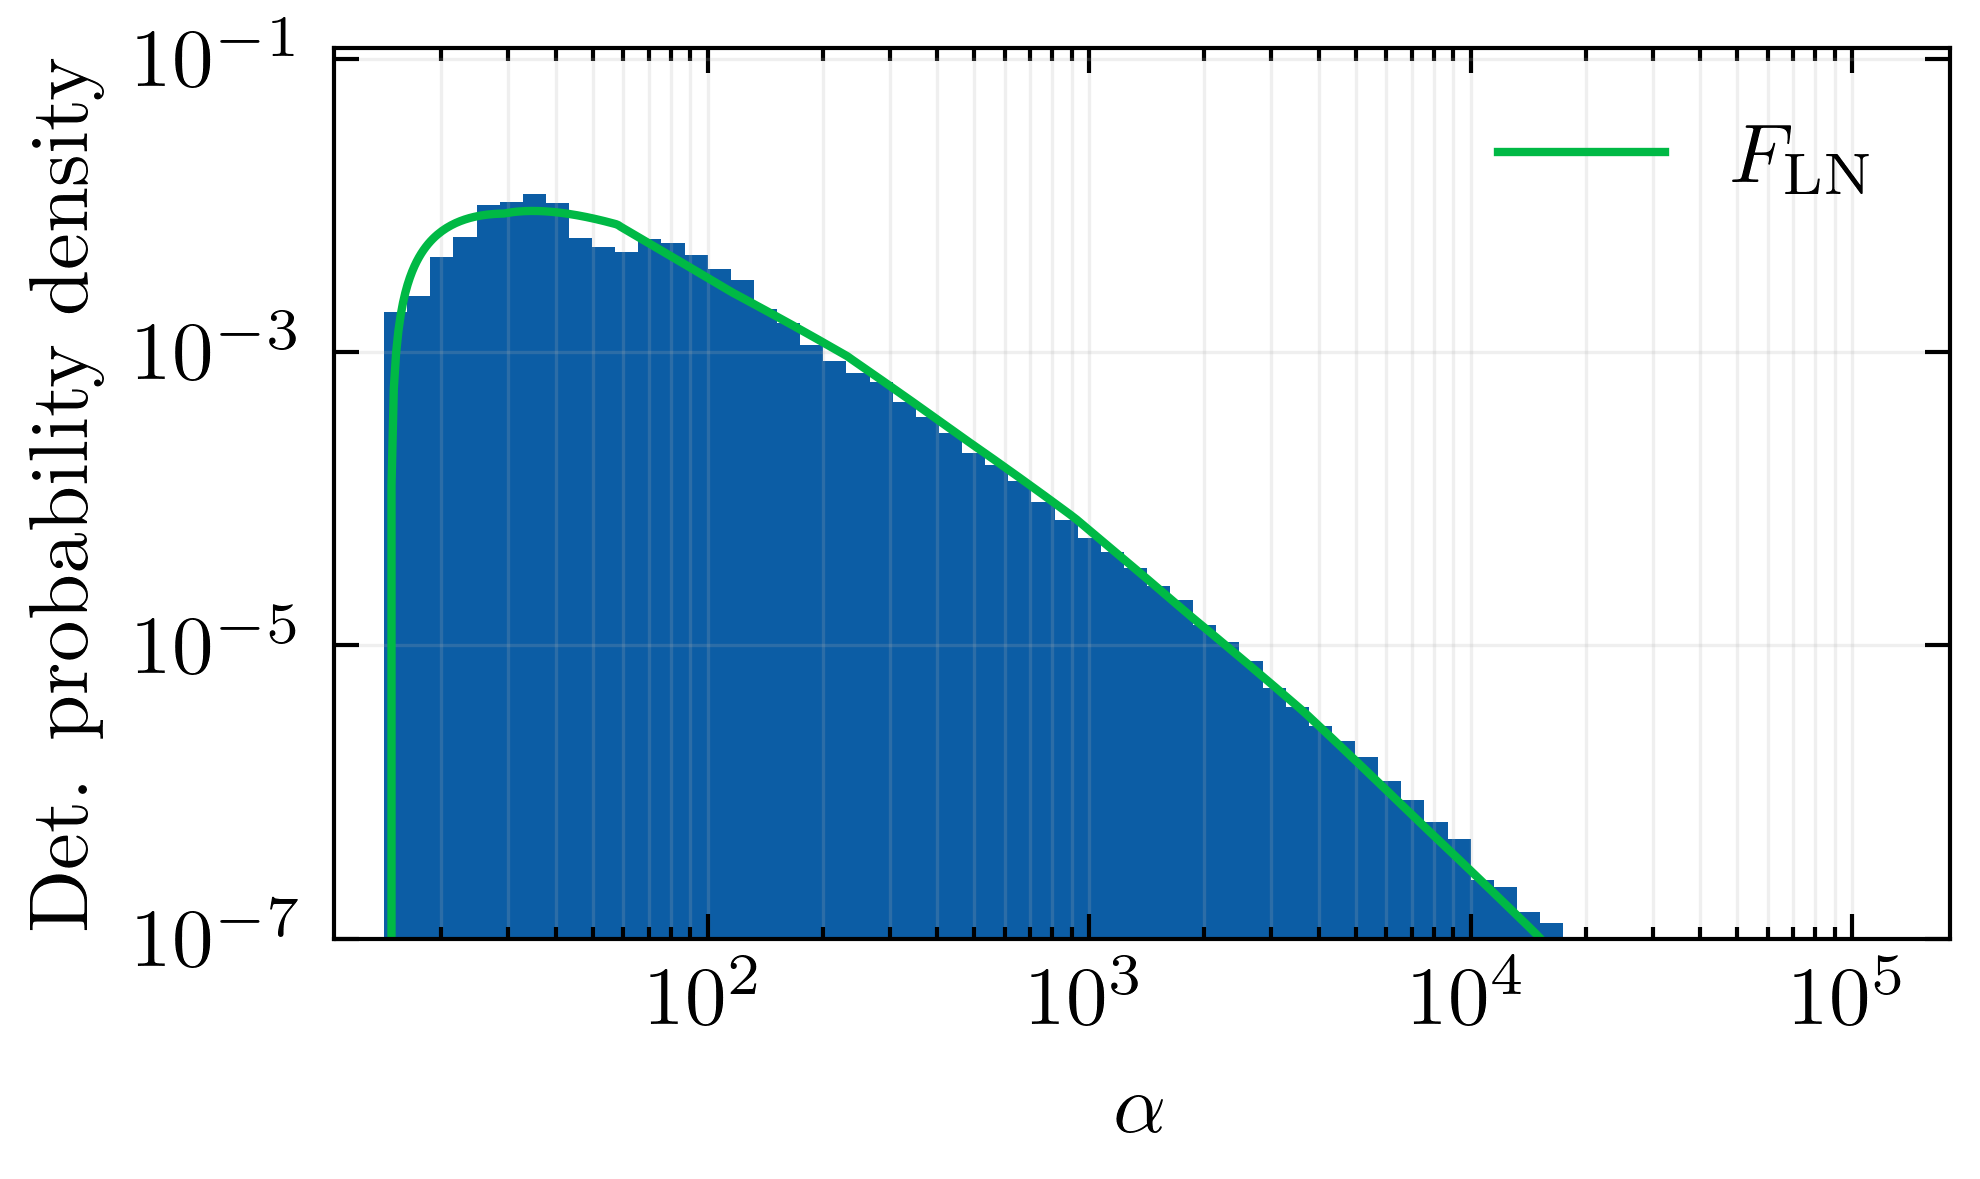

In [ ]:
alphas_hist = np.geomspace(1, 1e6, 100)
alphas = np.geomspace(1, 1e6, 1000)

counts, bins, _ = plt.hist(fit.cleaned_data.collect()["alpha"].to_numpy(),
                           alphas_hist, density = True)

fit_params = LogNormalFitParams(*mle_model.params)
plt.plot(alphas, fit.F_norm(alphas, fit_params, sm.best_p_function), label = r"$F_{\text{LN}}$")

plt.ylim(1e-7, counts.max() * 10)
plt.xlim(fit.plot_range[0] * 0.7, fit.plot_range[1] * 0.5)
plt.xscale("log")
plt.xlabel(r"$\alpha$")
plt.yscale("log")
plt.ylabel("Det. probability density")
plt.legend()
plt.grid(which='both', linestyle='-', linewidth=0.4, alpha=0.2)
plt.tight_layout()
plt.show()

In [ ]:
from datetime import datetime

output_dir = Path("MLE_fit_data/LogNormal")

while True:
    df = fit.MultiMLEFit(
        optimize_params=LogNormalFitParams(mu=-2.302585093, sigma=2),
        numb_runs=1,
        summary = False
    )

    # Filename based on current datetime (to the second)
    timestamp: str = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    filename: Path = output_dir / f"{timestamp}.parquet"

    df.write_parquet(filename)

    print(f"Saved {filename}")

MultiMLE fit running:   0%|          | 0/1 [00:00<?, ?it/s]

Optimization terminated successfully.
         Current function value: 6.167717
         Iterations: 49
         Function evaluations: 94


MultiMLE fit running: 100%|██████████| 1/1 [01:35<00:00, 95.43s/it]


                              TheoryFit Results                               
Dep. Variable:                      y   Log-Likelihood:            -2.6182e+06
Model:                      TheoryFit   AIC:                         5.236e+06
Method:            Maximum Likelihood   BIC:                         5.236e+06
Date:                Mon, 29 Jun 2026                                         
Time:                        15:35:30                                         
No. Observations:              424494                                         
Df Residuals:                  424492                                         
Df Model:                           2                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
par0          -5.8214      0.046   -127.498      0.000      -5.911      -5.732
par1           2.4151      0.012    206.218      0.0

MultiMLE fit running:   0%|          | 0/1 [00:00<?, ?it/s]

...

Optimization terminated successfully.
         Current function value: 6.160873
         Iterations: 56
         Function evaluations: 110


MultiMLE fit running: 100%|██████████| 1/1 [01:55<00:00, 115.54s/it]


                              TheoryFit Results                               
Dep. Variable:                      y   Log-Likelihood:            -2.6153e+06
Model:                      TheoryFit   AIC:                         5.231e+06
Method:            Maximum Likelihood   BIC:                         5.231e+06
Date:                Mon, 29 Jun 2026                                         
Time:                        15:40:20                                         
No. Observations:              424494                                         
Df Residuals:                  424492                                         
Df Model:                           2                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
par0          -3.4388      0.014   -244.282      0.000      -3.466      -3.411
par1           1.8137      0.006    322.789      0.0

MultiMLE fit running:   0%|          | 0/1 [01:26<?, ?it/s]


KeyboardInterrupt: 